In [10]:
import numpy as np
import matplotlib.pyplot as plt
#import jax_kernels as ker 
import functions as f

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal


We aim at minimizing $$\mathcal{F}_P(Q) = \mathcal{L}(Q) + D_{KL}(Q||Q_0)$$ where $Q_0 = \mathcal{N}(0,I_d)$ and $P$ is the minimizer and has a positive density $$p(x) \propto q_0(x) \exp(-\mathcal{L}'(P)(x)).$$



In [11]:
def kl_divergence_kde(X, num_samples=1000):
    n, d = X.shape
    
    # KDE approximation using JAX
    def kde_density(data, points, bandwidth=1.0):
        diff = jnp.expand_dims(points, axis=1) - jnp.expand_dims(data, axis=0)  # (num_samples, n, d)
        dist = jnp.linalg.norm(diff, axis=2)  # (num_samples, n)
        weights = jnp.exp(-dist**2 / (2 * bandwidth**2))  # (num_samples, n)
        density = jnp.sum(weights, axis=1) / (n * (bandwidth * jnp.sqrt(2 * jnp.pi))**d)
        return jnp.log(density)

    # Resample points from KDE
    samples = X[np.random.choice(n, num_samples, replace=True)]  # Resampling from X
    log_qn = kde_density(X, samples)  # Log density of KDE at sampled points

    # Log density of standard Gaussian
    log_q0 = multivariate_normal.logpdf(samples, mean=jnp.zeros(d), cov=jnp.eye(d))

    # KL divergence estimate
    kl_estimate = jnp.mean(log_qn - log_q0)
    return kl_estimate

def q_0(X):
    return jnp.exp(-jnp.linalg.norm(X,axis= 1)**2 / 2) / jnp.sqrt(2 * jnp.pi)
def F(L,X):
    n = len(X)
    KL = kl_divergence_kde(X)
    return L(X) + KL

# I/ Gaussian kernel  : $k(x,y) = e^{\frac{-\|x-y\|^2}{2}}$.

# 1. Sanity Check 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [12]:
sigma = 1.0
def k(x,y):
    return jnp.exp(-jnp.dot(x-y,x-y) / (2*sigma**2))

def s_q0(X): 
    return -X
def v(X):
    return -1/4 * np.linalg.norm(X, axis=1)**2 
def L(X):
    return np.mean(v(X))
def _grad_v(X):
    return -X/2 
def grad_L(X):
    return _grad_v(X) 
def gradV(X):
    return grad_L(X) - s_q0(X)
def s_pq(X):
    return -gradV(X)

def dlogp(x):
    return -x/2

k_PQ = f.GradientKernel(s_pq,k)
KGD = f.KernelGradientDiscrepancy(k_PQ)



Sanity check : we plot $KGD_P(\hat{P}_n)$ where $\hat{P}_n$ is a discrete distribution supported on $n$ i.i.d. samples from $P = \mathcal{N}(0,2I_d)$. We plot this for increasing values of $n$.

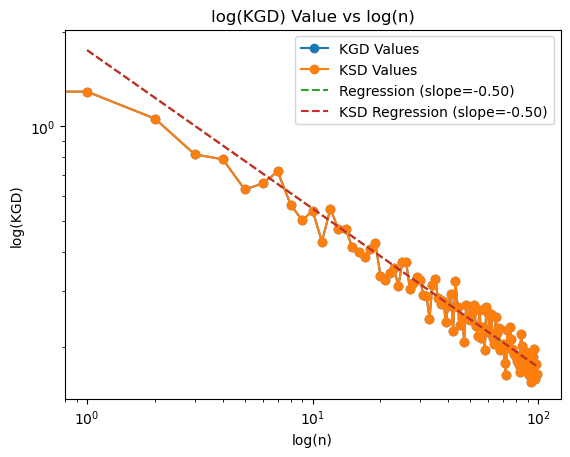

Slope of regression line: -0.50
Slope of KSD regression line: -0.50


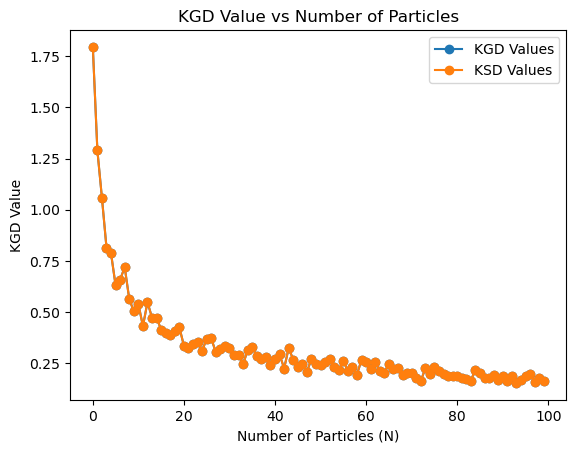

In [13]:


stein_kernel = f.GradientKernel(dlogp, k)
KSD = f.KernelGradientDiscrepancy(stein_kernel)

N_max = 100
KGD_N = [] 
KSD_N = [] 
m = 3
for n in range(1,N_max+1):
    kgd_n = 0
    ksd_n = 0
    for i in range(m):
        x = np.random.randn(n, 2)
        kgd_n += 1/m * KGD.evaluate(jnp.sqrt(2) * x)
        ksd_n += 1/m * KSD.evaluate(jnp.sqrt(2) * x)
    KSD_N.append(ksd_n)
    KGD_N.append(kgd_n)
KGD_N = jnp.asarray(KGD_N)
KSD_N = jnp.asarray(KSD_N)




# Log-log transformation
log_N = jnp.log(jnp.arange(1, N_max + 1))  # Log of particle numbers
log_KGD_N = jnp.log(KGD_N)  # Log of KGD values
log_KSD_N = jnp.log(KSD_N)  # Log of KSD values
# Linear regression in log-log space
A = jnp.vstack([log_N, jnp.ones_like(log_N)]).T  # Design matrix
coef, intercept = jnp.linalg.lstsq(A, log_KGD_N, rcond=None)[0]  # Solve Ax = b
coef_ksd, intercept_ksd = jnp.linalg.lstsq(A, log_KSD_N, rcond=None)[0]  # Solve Ax = b for KSD

# Plotting
plt.plot(KGD_N, marker='o', label='KGD Values')
plt.plot(KSD_N, marker='o', label='KSD Values')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(n)')
plt.ylabel('log(KGD)')
plt.title('log(KGD) Value vs log(n)')
plt.legend()

# Display regression line
plt.plot(jnp.exp(log_N), jnp.exp(coef * log_N + intercept), label=f'Regression (slope={coef:.2f})', linestyle='--')
plt.plot(jnp.exp(log_N), jnp.exp(coef_ksd * log_N + intercept_ksd), label=f'KSD Regression (slope={coef_ksd:.2f})', linestyle='--')
plt.legend()
plt.show()

print(f"Slope of regression line: {coef:.2f}")
print(f"Slope of KSD regression line: {coef_ksd:.2f}")


plt.figure()
# Plotting
plt.plot(KGD_N, marker='o', label='KGD Values')
plt.plot(KSD_N, marker='o', label='KSD Values')
plt.xlabel('Number of Particles (N)')
plt.ylabel('KGD Value')
plt.title('KGD Value vs Number of Particles')
plt.legend()

[]